<a href="https://colab.research.google.com/github/chethankmgowda/Projects/blob/main/Capstone1_NHANES_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone Project 1: Working with `numpy` Matrices (Multidimensional Data)

**A comparative analysis of adult male and female body measurements (NHANES 2017–2020)**

---

### Overview

This report analyses body measurement data collected as part of the [National Health and
Nutrition Examination Survey](https://www.cdc.gov/nchs/nhanes/index.htm) (NHANES), conducted
by the US Centers for Disease Control and Prevention. Two excerpts of the survey are used,
covering seven body measurements — weight, standing height, upper arm length, upper leg
length, arm circumference, hip circumference, and waist circumference — recorded separately
for adult males and females.

The purpose of this report is to explore, describe, and compare the distributions of these
measurements between sexes, to derive several commonly used body-composition indices (the
Body Mass Index, the waist-to-height ratio, and the waist-to-hip ratio), and to examine the
relationships between the underlying variables using standardised (z-score) data and
correlation analysis.

The datasets were obtained from Prof. Marek Gagolewski's teaching data repository
(<https://github.com/gagolews/teaching-data/tree/master/marek>), files
`nhanes_adult_male_bmx_2020.csv` and `nhanes_adult_female_bmx_2020.csv`.


## 1. Setup

The following code cell imports the packages required throughout this notebook: `numpy`
for numerical/matrix computations, `matplotlib.pyplot` for plotting, and `scipy.stats` for
correlation coefficients and descriptive statistics (skewness and kurtosis).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats

np.set_printoptions(precision=3, suppress=True)
plt.rcParams["figure.figsize"] = (8, 5)


## 2. Reading the Data

The two CSV files, `nhanes_adult_male_bmx_2020.csv` and `nhanes_adult_female_bmx_2020.csv`,
are read directly from Prof. Marek Gagolewski's teaching data repository on GitHub
(<https://github.com/gagolews/teaching-data/tree/master/marek>), using their raw file URLs.
Each file begins with a block of comment lines (starting with `#`) describing the dataset,
followed by a header row giving the column names, followed by the numeric data itself.

`pandas.read_csv` is used to fetch and parse each file in a single step: the `comment="#"`
argument instructs pandas to automatically skip every comment line (and correctly treat the
following line as the header row), while pandas' native support for URL sources means the
data does not need to be downloaded manually beforehand. The resulting DataFrame is then
converted into a plain two-dimensional `numpy` array — i.e., a matrix — via `.to_numpy()`.
Each matrix has seven columns, in the following order: weight (kg), standing height (cm),
upper arm length (cm), upper leg length (cm), arm circumference (cm), hip circumference
(cm), and waist circumference (cm).

In [3]:
import pandas as pd

male_url = "https://raw.githubusercontent.com/gagolews/teaching-data/master/marek/nhanes_adult_male_bmx_2020.csv"
female_url = "https://raw.githubusercontent.com/gagolews/teaching-data/master/marek/nhanes_adult_female_bmx_2020.csv"

male = pd.read_csv(male_url, comment="#").to_numpy()
female = pd.read_csv(female_url, comment="#").to_numpy()

columns = [
    "weight (kg)", "standing height (cm)", "upper arm length (cm)",
    "upper leg length (cm)", "arm circumference (cm)",
    "hip circumference (cm)", "waist circumference (cm)",
]

print(f"male   matrix shape: {male.shape}")
print(f"female matrix shape: {female.shape}")
print()
print("First three rows of `male`:")
print(male[:3, :])
print()
print("First three rows of `female`:")
print(female[:3, :])


male   matrix shape: (4081, 7)
female matrix shape: (4221, 7)

First three rows of `male`:
[[ 98.8 182.3  42.   40.1  38.2 108.2 120.4]
 [ 74.3 184.2  41.1  41.   30.2  94.5  86.8]
 [103.7 185.3  47.   44.   32.  107.8 109.6]]

First three rows of `female`:
[[ 97.1 160.2  34.7  40.8  35.8 126.1 117.9]
 [ 91.1 152.7  33.5  33.   38.5 125.5 103.1]
 [ 73.  161.2  37.4  38.   31.8 106.2  92. ]]


The `male` matrix holds 4,081 observations and the `female` matrix holds 4,221
observations, each with seven body measurements. Neither matrix contains missing (`NaN`)
values, confirming that the files were loaded correctly and that this excerpt of NHANES is
already complete.


## 3. Weight Distributions: Histograms

To compare how body weight is distributed between the two sexes, histograms of female and
male weights are plotted on a single figure using `matplotlib.pyplot.subplot`: the female
histogram on top, the male histogram on the bottom. The x-axis limits are fixed to be
identical on both subfigures (based on the overall minimum and maximum weight observed
across both sexes, with a small margin) so that the two distributions can be compared
directly, bar for bar.


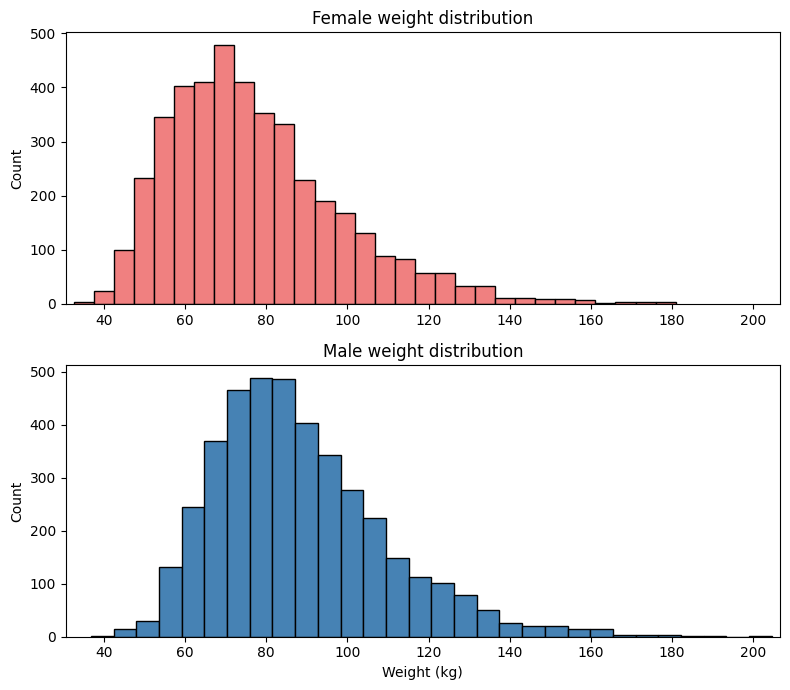

In [4]:
female_weight = female[:, 0]
male_weight = male[:, 0]

xmin = min(female_weight.min(), male_weight.min()) - 2
xmax = max(female_weight.max(), male_weight.max()) + 2

fig = plt.figure(figsize=(8, 7))

plt.subplot(2, 1, 1)
plt.hist(female_weight, bins=30, color="lightcoral", edgecolor="black")
plt.xlim(xmin, xmax)
plt.title("Female weight distribution")
plt.ylabel("Count")

plt.subplot(2, 1, 2)
plt.hist(male_weight, bins=30, color="steelblue", edgecolor="black")
plt.xlim(xmin, xmax)
plt.title("Male weight distribution")
plt.xlabel("Weight (kg)")
plt.ylabel("Count")

plt.tight_layout()
plt.show()


Both distributions are unimodal and right-skewed (a longer tail towards higher
weights), which is typical of human body-weight data: weight is bounded below by zero but
can extend considerably above the average due to obesity, while it cannot fall symmetrically
far below it. On the shared x-axis, the male distribution is visibly shifted to the right of
the female distribution, indicating that, on average, men in the sample are heavier than
women. The male distribution also appears slightly more spread out along the upper tail.


## 4. Weight Distributions: Box-and-Whisker Plot

A box-and-whisker plot provides a complementary, more compact view of the same two weight
distributions, making it easy to compare their medians, interquartile ranges, and outliers
side by side.


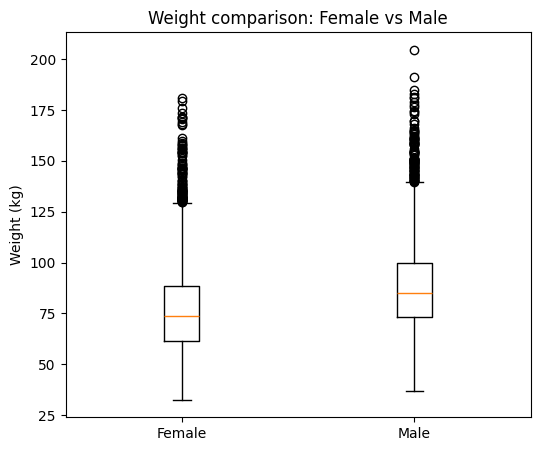

In [5]:
fig = plt.figure(figsize=(6, 5))
plt.boxplot([female_weight, male_weight], tick_labels=["Female", "Male"])
plt.ylabel("Weight (kg)")
plt.title("Weight comparison: Female vs Male")
plt.show()


The boxplot confirms the observations made from the histograms. The male box (and its
median line) sits noticeably higher than the female box, consistent with men being heavier
on average. Both groups display a considerable number of points above the upper whisker,
reflecting the right-skewed nature of weight data, i.e. a subset of markedly heavier
individuals in both sexes. The female distribution's interquartile range (box height)
appears comparable to, or slightly narrower than, the male one, suggesting similar or
slightly lower relative dispersion among women once scale is accounted for.


## 5. Numerical Aggregates of Weight

The code below computes standard measures of location (mean, median), dispersion (standard
deviation, variance, interquartile range, range), and shape (skewness, kurtosis) for the male
and female weight vectors, to complement the graphical comparison above.


In [6]:
def summarise(x, label):
    q1, q3 = np.percentile(x, [25, 75])
    stats = {
        "n": len(x),
        "mean": np.mean(x),
        "median": np.median(x),
        "std (ddof=1)": np.std(x, ddof=1),
        "variance (ddof=1)": np.var(x, ddof=1),
        "min": np.min(x),
        "max": np.max(x),
        "range": np.max(x) - np.min(x),
        "Q1": q1,
        "Q3": q3,
        "IQR": q3 - q1,
        "skewness": scipy.stats.skew(x),
        "kurtosis (excess)": scipy.stats.kurtosis(x),
    }
    print(f"--- {label} weight ---")
    for k, v in stats.items():
        print(f"{k:>20s}: {v:10.3f}" if k != "n" else f"{k:>20s}: {v:10d}")
    print()
    return stats

female_stats = summarise(female_weight, "Female")
male_stats = summarise(male_weight, "Male")


--- Female weight ---
                   n:       4221
                mean:     77.404
              median:     73.600
        std (ddof=1):     21.545
   variance (ddof=1):    464.190
                 min:     32.600
                 max:    180.900
               range:    148.300
                  Q1:     61.600
                  Q3:     88.700
                 IQR:     27.100
            skewness:      1.033
   kurtosis (excess):      1.401

--- Male weight ---
                   n:       4081
                mean:     88.365
              median:     85.000
        std (ddof=1):     21.422
   variance (ddof=1):    458.883
                 min:     36.800
                 max:    204.600
               range:    167.800
                  Q1:     73.300
                  Q3:     99.800
                 IQR:     26.500
            skewness:      0.984
   kurtosis (excess):      1.474



**Discussion.** The mean male weight is noticeably higher than the mean female weight,
and the male median exceeds the female median by a similar margin, confirming the visual
impression from the histograms and boxplot. In both groups, the mean is somewhat larger than
the median, and the skewness statistic is positive, confirming that both distributions are
right-skewed (a small number of comparatively very heavy participants pull the mean upward
relative to the median) rather than left-skewed.

In terms of dispersion, the female and male standard deviations and IQRs are, in absolute
terms, very close to one another (female weight is, in fact, marginally *more* spread out
than male weight, both by standard deviation and by IQR), even though male weight is on
average almost 11 kg higher. This means that, *relative* to their respective means, male
weights are somewhat less variable than female weights (a smaller coefficient of variation),
i.e. the female distribution is proportionally more dispersed. Both distributions show
positive excess kurtosis, meaning that they are more sharply peaked, with heavier tails, than
a Normal distribution would predict — consistent with the presence of the higher-weight
outliers visible in the boxplot.


## 6. Adding Body Mass Index (BMI) to the Female Matrix

The Body Mass Index is defined as $\mathrm{BMI} = \dfrac{\text{weight (kg)}}{\text{height
(m)}^2}$. It is computed for every female participant and appended to the `female` matrix as
an eighth column.


In [7]:
female_bmi = female[:, 0] / (female[:, 1] / 100) ** 2
female = np.hstack([female, female_bmi.reshape(-1, 1)])
columns_female = columns + ["BMI (kg/m^2)"]

print(f"female matrix shape after adding BMI: {female.shape}")
print("First three rows (now 8 columns):")
print(female[:3, :])


female matrix shape after adding BMI: (4221, 8)
First three rows (now 8 columns):
[[ 97.1   160.2    34.7    40.8    35.8   126.1   117.9    37.835]
 [ 91.1   152.7    33.5    33.     38.5   125.5   103.1    39.07 ]
 [ 73.    161.2    37.4    38.     31.8   106.2    92.     28.093]]


The `female` matrix now has eight columns, with BMI as the final one. A brief sanity
check confirms that the computed BMI values fall within a plausible physiological range
(roughly 15–75 kg/m² in this sample), as expected for adult body-measurement data.


## 7. Standardising the Female Data (`zfemale`)

A new matrix, `zfemale`, is created by converting every column of `female` (including the
newly added BMI column) into z-scores: $z = \dfrac{x - \bar{x}}{s}$, where $\bar{x}$ is the
column mean and $s$ is the column standard deviation. After standardisation, every column of
`zfemale` has a mean of (approximately) 0 and a standard deviation of 1, which allows
variables originally measured on very different scales (e.g., weight in kilograms versus
height in centimetres) to be compared directly.


In [8]:
female_mean = female.mean(axis=0)
female_std = female.std(axis=0, ddof=0)
zfemale = (female - female_mean) / female_std

print("Column means of zfemale (should all be ~0):")
print(zfemale.mean(axis=0))
print()
print("Column standard deviations of zfemale (should all be 1):")
print(zfemale.std(axis=0))


Column means of zfemale (should all be ~0):
[-0.  0.  0.  0.  0.  0. -0.  0.]

Column standard deviations of zfemale (should all be 1):
[1. 1. 1. 1. 1. 1. 1. 1.]


## 8. Scatterplot Matrix and Correlation Analysis (Female Data)

To explore the relationships between five key female body measurements — standing height,
weight, waist circumference, hip circumference, and BMI — a scatterplot matrix (pairplot) is
drawn using their standardised (z-score) versions from `zfemale`. Pearson's correlation
coefficient (linear association) and Spearman's rank correlation coefficient (monotonic
association) are also computed for every pair of these variables.


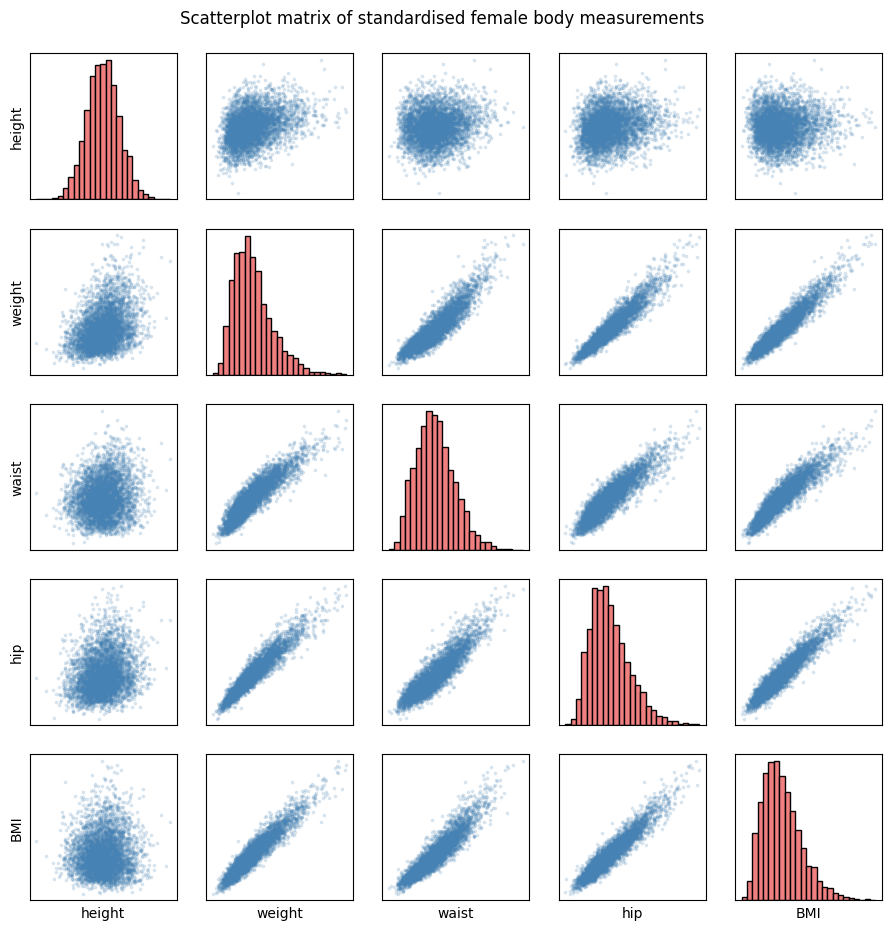

In [9]:
var_names = ["height", "weight", "waist", "hip", "BMI"]
var_idx = [1, 0, 6, 5, 7]  # indices into (z)female matching var_names
Z = zfemale[:, var_idx]

n = len(var_names)
fig, axes = plt.subplots(n, n, figsize=(11, 11))
for i in range(n):
    for j in range(n):
        ax = axes[i, j]
        if i == j:
            ax.hist(Z[:, i], bins=25, color="lightcoral", edgecolor="black")
        else:
            ax.scatter(Z[:, j], Z[:, i], s=3, alpha=0.15, color="steelblue")
        if i == n - 1:
            ax.set_xlabel(var_names[j])
        if j == 0:
            ax.set_ylabel(var_names[i])
        ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Scatterplot matrix of standardised female body measurements", y=0.92)
plt.show()


In [10]:
pearson_corr = np.corrcoef(Z, rowvar=False)
spearman_corr, _ = scipy.stats.spearmanr(Z)

def print_matrix(M, title):
    print(title)
    header = "        " + "".join(f"{v:>9s}" for v in var_names)
    print(header)
    for i, row_name in enumerate(var_names):
        row = "".join(f"{M[i, j]:9.3f}" for j in range(n))
        print(f"{row_name:>8s}{row}")
    print()

print_matrix(pearson_corr, "Pearson correlation coefficients:")
print_matrix(spearman_corr, "Spearman correlation coefficients:")


Pearson correlation coefficients:
           height   weight    waist      hip      BMI
  height    1.000    0.345    0.127    0.203    0.033
  weight    0.345    1.000    0.905    0.947    0.946
   waist    0.127    0.905    1.000    0.897    0.921
     hip    0.203    0.947    0.897    1.000    0.944
     BMI    0.033    0.946    0.921    0.944    1.000

Spearman correlation coefficients:
           height   weight    waist      hip      BMI
  height    1.000    0.339    0.109    0.205    0.020
  weight    0.339    1.000    0.900    0.947    0.938
   waist    0.109    0.900    1.000    0.888    0.923
     hip    0.205    0.947    0.888    1.000    0.934
     BMI    0.020    0.938    0.923    0.934    1.000



**Interpretation.** Weight is strongly, positively correlated with waist circumference,
hip circumference, and BMI (Pearson coefficients well above 0.8 for waist and BMI), which is
expected, since all of these are direct or near-direct measures of body size. Waist
circumference and BMI are also very strongly correlated with one another, as both largely
reflect adiposity. Height shows only weak correlations with the other variables (its
correlation with weight is modest and positive, while its correlation with BMI is close to
zero or slightly negative), because BMI is specifically constructed to adjust weight for
height, largely removing the linear relationship between the two. The Spearman coefficients
closely track the Pearson coefficients throughout, which suggests that the relationships
between these variables are reasonably close to linear (monotonic and roughly straight-line),
without strong non-linear distortions; where small differences do appear (e.g., very slightly
higher Spearman than Pearson values for some pairs), these hint at mild non-linearity or the
influence of a few extreme values on the Pearson estimate.


## 9. Waist-to-Height and Waist-to-Hip Ratios

Two further body-shape indices are computed for both sexes and appended as extra columns to
the `male` and `female` matrices: the **waist-to-height ratio** (waist circumference divided
by standing height) and the **waist-to-hip ratio** (waist circumference divided by hip
circumference).


In [11]:
# indices in the *original* 7-column layout: 0=weight,1=height,5=hip,6=waist
male_wthr = male[:, 6] / male[:, 1]
male_whr = male[:, 6] / male[:, 5]
male = np.hstack([male, male_wthr.reshape(-1, 1), male_whr.reshape(-1, 1)])

# female currently has 8 columns (BMI already appended); waist/hip are still at 5/6
female_wthr = female[:, 6] / female[:, 1]
female_whr = female[:, 6] / female[:, 5]
female = np.hstack([female, female_wthr.reshape(-1, 1), female_whr.reshape(-1, 1)])

print(f"male matrix shape:   {male.shape}   (7 original + waist-to-height + waist-to-hip)")
print(f"female matrix shape: {female.shape}   (8 with BMI + waist-to-height + waist-to-hip)")


male matrix shape:   (4081, 9)   (7 original + waist-to-height + waist-to-hip)
female matrix shape: (4221, 10)   (8 with BMI + waist-to-height + waist-to-hip)


## 10. Comparing the Ratios Between Sexes

A single box-and-whisker plot with four boxes side by side compares the waist-to-height and
waist-to-hip ratios of male and female participants.


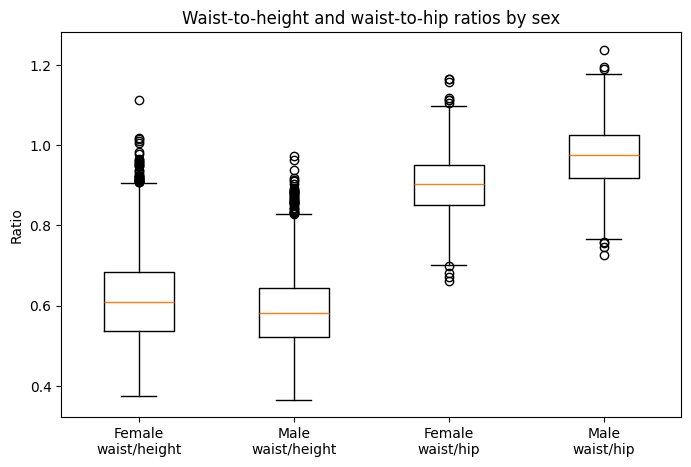

In [12]:
fig = plt.figure(figsize=(8, 5))
data_to_plot = [female_wthr, male_wthr, female_whr, male_whr]
labels = ["Female\nwaist/height", "Male\nwaist/height", "Female\nwaist/hip", "Male\nwaist/hip"]
plt.boxplot(data_to_plot, tick_labels=labels)
plt.ylabel("Ratio")
plt.title("Waist-to-height and waist-to-hip ratios by sex")
plt.show()


The waist-to-height ratio is fairly similar between the sexes, with the male median
slightly above the female one and comparable spread — this reflects the fact that men, being
on average taller, tend to carry proportionally more of their extra waist circumference
relative to their height in a way not too dissimilar from women. The waist-to-hip ratio, by
contrast, shows a much clearer separation: the male distribution sits distinctly above the
female one with limited overlap. This is consistent with well-documented differences in body
fat distribution between sexes — men typically accumulate fat more centrally (an "apple"
shape, larger waist relative to hips), while women more often show a comparatively larger hip
circumference relative to the waist (a "pear" shape) due to differences in pelvic structure
and typical fat storage patterns. The waist-to-hip ratio therefore appears to be a more
sex-discriminating shape index in this sample than the waist-to-height ratio.


## 11. BMI, Waist-to-Height Ratio, and Waist-to-Hip Ratio: A Comparison

Each of these three indices offers a different, partial view of body composition, and each
comes with its own strengths and limitations.

**Body Mass Index (BMI = weight / height²)**
- *Advantages*: extremely simple to compute from just two commonly available measurements;
  well-established, widely used and understood by clinicians and the public; useful for
  population-level screening and epidemiological comparisons.
- *Disadvantages*: does not distinguish between fat mass and muscle mass, so it can
  misclassify very muscular individuals as overweight and very unfit but low-weight
  individuals as normal; does not capture where fat is distributed on the body, even though
  central (abdominal) fat carries greater cardiometabolic risk than fat stored elsewhere;
  its interpretation can also vary across ethnic groups, ages, and sexes.

**Waist-to-height ratio (waist / height)**
- *Advantages*: directly reflects central adiposity, which is more strongly linked to
  cardiometabolic risk than overall body size; still simple to measure; a single
  approximate threshold (e.g., "keep your waist to less than half your height") works
  reasonably well across a wide range of heights, ages, and, to some extent, sexes and
  ethnicities.
- *Disadvantages*: waist circumference measurement is less standardised in practice than
  height or weight (it depends on where exactly, and how tightly, the tape is placed) and
  can be affected by recent food or fluid intake; it still does not distinguish fat from
  muscle in the abdominal region, nor account for frame size.

**Waist-to-hip ratio (waist / hip)**
- *Advantages*: captures body *shape* (central versus peripheral fat distribution) rather
  than just size, and is a good predictor of cardiometabolic risk, arguably better than BMI
  for this purpose; as seen in Section 10, it clearly differentiates typical male and female
  fat-distribution patterns.
- *Disadvantages*: requires two circumference measurements rather than one, compounding
  measurement error; hip circumference itself can be strongly influenced by muscle and
  skeletal (pelvic) structure rather than fat alone, which can distort the ratio; less
  intuitive for the general public than BMI; cut-off values are less universally agreed upon.

In summary, no single index is perfect: BMI is the simplest and most widely recognised
measure of overall size, but waist-based ratios are generally considered better indicators of
the health-relevant central fat distribution. In practice, these indices are often best used
together, alongside clinical judgement, rather than relied upon in isolation.


## 12. Standardised Measurements of the Extreme-BMI Participants

Finally, the standardised body measurements (from `zfemale`) of the five female participants
with the *lowest* BMI and the five with the *highest* BMI are printed, using
`numpy.argsort` on the BMI column (column index 7) to identify the relevant rows.


In [13]:
bmi_col = 7  # BMI's column index within the 8-column `female` / `zfemale` matrices
order = np.argsort(zfemale[:, bmi_col])

lowest5_idx = order[:5]
highest5_idx = order[-5:]
selected_idx = np.concatenate([lowest5_idx, highest5_idx])

header = "".join(f"{c.split(' (')[0]:>12s}" for c in columns_female)
print("        " + header)
print("--- 5 participants with the LOWEST BMI ---")
for i in lowest5_idx:
    row = "".join(f"{v:12.2f}" for v in zfemale[i, :])
    print(f"row {i:5d}{row}")

print()
print("--- 5 participants with the HIGHEST BMI ---")
for i in highest5_idx:
    row = "".join(f"{v:12.2f}" for v in zfemale[i, :])
    print(f"row {i:5d}{row}")


              weightstanding heightupper arm lengthupper leg lengtharm circumferencehip circumferencewaist circumference         BMI
--- 5 participants with the LOWEST BMI ---
row   262       -2.08       -1.22       -1.55       -1.17       -2.19       -2.04       -1.94       -2.05
row  3478       -1.88       -0.19       -1.72        0.39       -2.44       -1.85       -2.06       -1.99
row  2126       -1.54        1.81        0.63        0.57       -2.27       -1.68       -1.71       -1.97
row  2753       -1.84       -0.26       -0.23        0.51       -2.30       -2.25       -1.86       -1.94
row  1209       -1.61        0.89       -0.10        0.48       -2.21       -1.83       -1.71       -1.89

--- 5 participants with the HIGHEST BMI ---
row  2268        4.25        0.29        1.86       -0.98        2.37        4.10        3.82        4.40
row  3022        4.46        0.50        1.69       -1.14        3.35        3.98        2.90        4.46
row  1472        4.35        0.28    

**Interpretation.** As expected by construction, the five lowest-BMI participants show
strongly negative standardised BMI values (well below the sample mean), while the five
highest-BMI participants show strongly positive ones (several standard deviations above the
mean) — the highest-BMI groups' values are notably more extreme in magnitude than the
lowest-BMI group's, again reflecting the right-skewed nature of BMI (and weight) noted
earlier: it is easier to be many standard deviations *above* average weight than *below* it,
since weight cannot go far below zero.

Looking across the other columns, the lowest-BMI participants also tend to show negative
z-scores for weight, arm circumference, hip circumference, and waist circumference — i.e.,
low BMI is generally accompanied by smaller values on essentially every other size-related
measurement, not only weight. Conversely, the highest-BMI participants show strongly positive
z-scores on these same measurements. Standing height, upper arm length, and upper leg length,
however, do not follow a clear pattern in either group, which is consistent with the weak
correlations observed between height and BMI in Section 8: BMI is essentially independent of
skeletal height, so extreme BMI values are not systematically associated with being
particularly tall or short.


## Conclusion

This analysis compared adult male and female body measurements from the NHANES survey.
Males were found to be, on average, heavier and taller than females, with both weight
distributions being right-skewed. Standardising the female measurements and examining
pairwise correlations showed that weight, waist circumference, hip circumference, and BMI are
all strongly inter-related, while height is comparatively independent of BMI. The
waist-to-hip ratio distinguished the sexes considerably more clearly than the waist-to-height
ratio, reflecting well-documented differences in typical fat distribution between men and
women. Finally, BMI, the waist-to-height ratio, and the waist-to-hip ratio were each shown to
carry complementary strengths and weaknesses as indicators of body composition and
cardiometabolic risk.
